In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import datetime as dt
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
print(f'Last run date: {dt.datetime.today()}')

Last run date: 2024-03-21 13:10:16.195849


### Constants

In [3]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
bool_clip_negative_loss = True

Project: 20231010-gen-xii
Task: 14_loss_forecasting
Subtask: 03_join_data


### Output dir

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant dir

In [5]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get all funded accounts all time

In [6]:
list_cols = [
    'bigAccountId',
    'FundingMonth_first',
    'intOpenBKType',
    'AmtFinanced',
    'BookValue',
    'loan_to_value',
    'DealerType',
]
str_filename = 'df_accounts.gzip'
str_uri = f's3://{str_project}/{str_task}/02_pull_tsp_data/{str_filename}'
df = pd.read_parquet(str_uri, columns=list_cols)
dict_rename = {
    'FundingMonth_first': 'dtmFunded_first',
}
df.rename(columns=dict_rename, inplace=True)
df

,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType
0,3,2000-06-01,NaN,24066.59,23377.9,1.029459,None
1,10,1998-10-01,NaN,11214.36,7525.0,1.490280,Franchise
2,44,1996-01-01,NaN,13031.38,11725.0,1.111418,None
3,69,2002-01-01,NaN,18521.08,12725.0,1.455488,None
4,119,1998-10-01,NaN,7377.36,7350.0,1.003722,Franchise
...,...,...,...,...,...,...,...
414066,7665722,2024-03-01,13.0,39368.73,30925.0,1.273039,Franchise
414067,7665939,2024-03-01,NaN,20352.08,15625.0,1.302533,Franchise
414068,7668528,2024-03-01,7.0,22191.53,17816.0,1.245596,Independent
414069,7668983,2024-03-01,NaN,17772.71,13525.0,1.314064,Independent


### Get loss at 24 and 72 months

In [7]:
list_cols = [
    'bigAccountId',
    'fltNetChgOff',
    'dtmFunded_first',
    'MonthEndDate_first',
    'months_on_books',
]
str_filename = 'df_loss.gzip'
str_uri = f's3://{str_project}/{str_task}/01_pull_data/{str_filename}'
df_tmp = pd.read_parquet(str_uri, columns=list_cols)
# subset to 24 or 72 months
df_tmp = df_tmp[(df_tmp['months_on_books'] == 24) | (df_tmp['months_on_books'] == 72)].copy()
df_tmp

,bigAccountId,fltNetChgOff,dtmFunded_first,MonthEndDate_first,months_on_books
235,1556017,17552.99,2014-04-01,2020-04-01,72
238,1542488,11191.08,2014-04-01,2020-04-01,72
276,1542519,470.38,2014-04-01,2020-04-01,72
283,1522057,327.17,2014-04-01,2020-04-01,72
291,1557758,5318.97,2014-04-01,2020-04-01,72
...,...,...,...,...,...
122437,5927894,252.37,2022-02-01,2024-02-01,24
122453,5911260,0.00,2022-02-01,2024-02-01,24
122454,5913559,300.00,2022-02-01,2024-02-01,24
122455,5922951,18.85,2022-02-01,2024-02-01,24


### Show freq

In [8]:
df_tmp['months_on_books'].value_counts(normalize=True)

months_on_books
72    0.772717
24    0.227283
Name: proportion, dtype: float64

## Accounts that went to loss only

In [9]:
df_tmp_2 = df_tmp.copy()
df_tmp_2 = pd.merge(
    left=df_tmp_2,
    right=df,
    on='bigAccountId',
    how='left',
)
df_tmp_2['prop_loss'] = df_tmp_2['fltNetChgOff'] / df_tmp_2['AmtFinanced']
if bool_clip_negative_loss:
    df_tmp_2['prop_loss'] = df_tmp_2['prop_loss'].clip(lower=0)
else:
    pass
df_tmp_2

,bigAccountId,fltNetChgOff,dtmFunded_first_x,MonthEndDate_first,months_on_books,dtmFunded_first_y,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType,prop_loss
0,1556017,17552.99,2014-04-01,2020-04-01,72,2014-04-01,13.0,18857.50,13800.0,1.366486,Independent,0.930823
1,1542488,11191.08,2014-04-01,2020-04-01,72,2014-04-01,NaN,21035.13,14200.0,1.481347,Franchise,0.532019
2,1542519,470.38,2014-04-01,2020-04-01,72,2014-04-01,NaN,10333.00,7750.0,1.333290,Independent,0.045522
3,1522057,327.17,2014-04-01,2020-04-01,72,2014-04-01,13.0,16110.00,11000.0,1.464545,Franchise,0.020309
4,1557758,5318.97,2014-04-01,2020-04-01,72,2014-04-01,NaN,18705.02,16447.0,1.137291,Franchise,0.284361
...,...,...,...,...,...,...,...,...,...,...,...,...
50685,5927894,252.37,2022-02-01,2024-02-01,24,2022-02-01,13.0,22446.40,19618.0,1.144174,Independent,0.011243
50686,5911260,0.00,2022-02-01,2024-02-01,24,2022-02-01,NaN,28102.24,22575.0,1.244839,Franchise,0.000000
50687,5913559,300.00,2022-02-01,2024-02-01,24,2022-02-01,NaN,32208.45,21663.0,1.486795,Franchise,0.009314
50688,5922951,18.85,2022-02-01,2024-02-01,24,2022-02-01,NaN,15709.96,11004.0,1.427659,Independent,0.001200


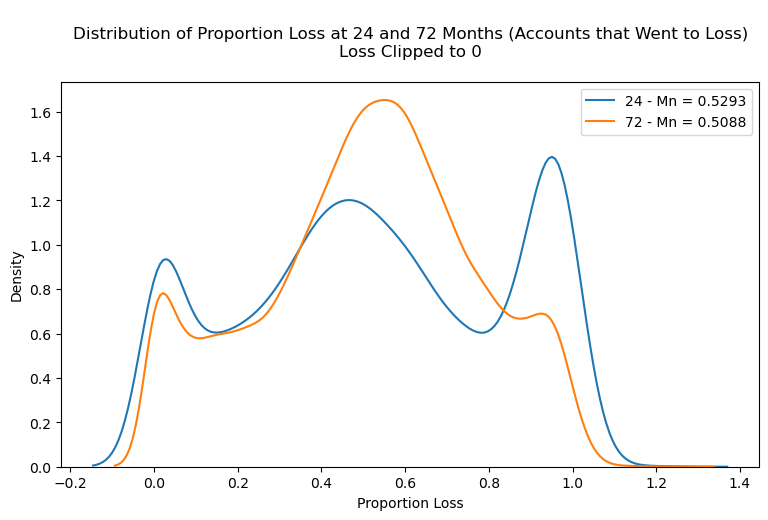

In [10]:
# 24
df_tmp_24 = df_tmp_2[df_tmp_2['months_on_books'] == 24].copy()
list_24 = list(df_tmp_24['prop_loss'])
flt_mean_24 = np.mean(list_24)
str_label_24 = f'24 - Mn = {flt_mean_24:0.4f}'
# 72
df_tmp_72 = df_tmp_2[df_tmp_2['months_on_books'] == 72].copy()
list_72 = list(df_tmp_72['prop_loss'])
flt_mean_72 = np.mean(list_72)
str_label_72 = f'72 - Mn = {flt_mean_72:0.4f}'
# title
str_title = f"""
Distribution of Proportion Loss at 24 and 72 Months (Accounts that Went to Loss)
Loss Clipped to 0
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Proportion Loss')
sns.kdeplot(list_24, ax=ax, label=str_label_24)
sns.kdeplot(list_72, ax=ax, label=str_label_72)
plt.legend()
plt.show()

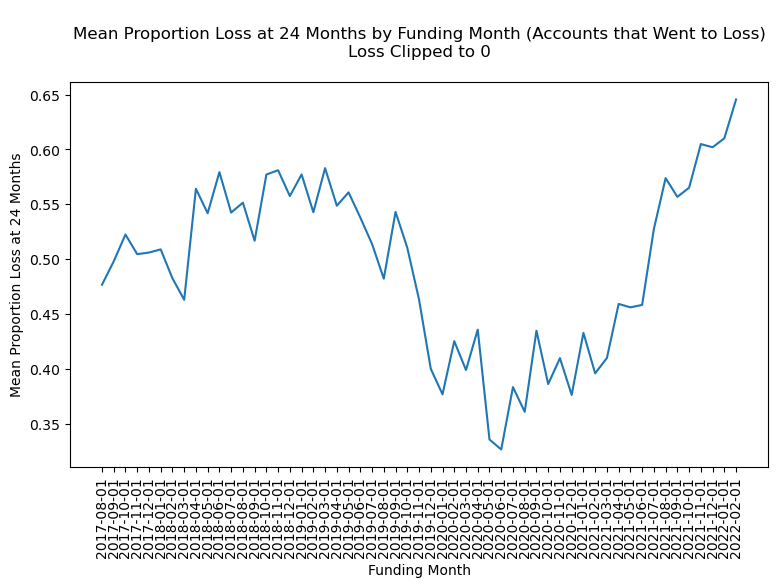

In [11]:
# loss over time
int_n_months = 24
df_tmp_tmp = df_tmp_2[df_tmp_2['months_on_books'] == int_n_months].copy()
df_tmp_tmp.sort_values(by='dtmFunded_first_x', ascending=True, inplace=True)
df_grouped = df_tmp_tmp.groupby(by='dtmFunded_first_x', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped['dtmFunded_first_x'] = df_grouped['dtmFunded_first_x'].astype(str)
# plot
str_title = f"""
Mean Proportion Loss at {int_n_months} Months by Funding Month (Accounts that Went to Loss)
Loss Clipped to 0
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Funding Month')
ax.set_ylabel(f'Mean Proportion Loss at {int_n_months} Months')
ax.plot(df_grouped['dtmFunded_first_x'], df_grouped['prop_loss'])
ax.set_xticklabels(df_grouped['dtmFunded_first_x'], rotation=90)
plt.show()

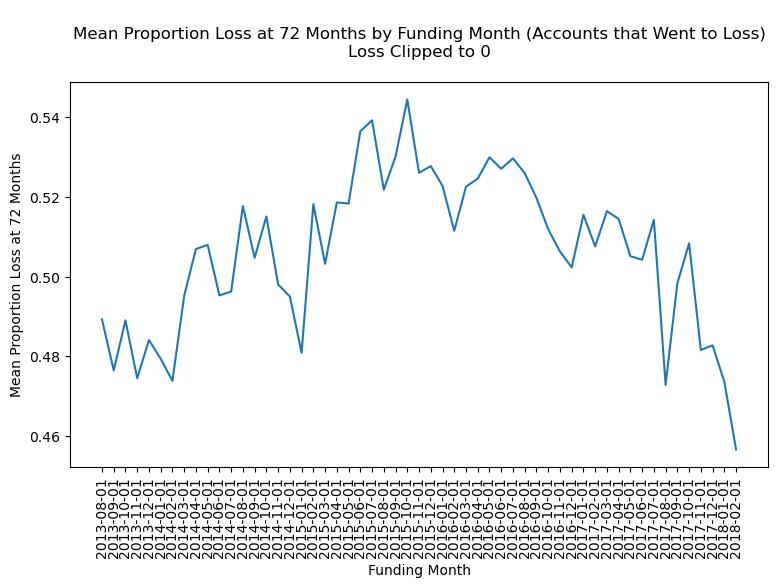

In [12]:
# loss over time
int_n_months = 72
df_tmp_tmp = df_tmp_2[df_tmp_2['months_on_books'] == int_n_months].copy()
df_tmp_tmp.sort_values(by='dtmFunded_first_x', ascending=True, inplace=True)
df_grouped = df_tmp_tmp.groupby(by='dtmFunded_first_x', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped['dtmFunded_first_x'] = df_grouped['dtmFunded_first_x'].astype(str)
# plot
str_title = f"""
Mean Proportion Loss at {int_n_months} Months by Funding Month (Accounts that Went to Loss)
Loss Clipped to 0
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Funding Month')
ax.set_ylabel(f'Mean Proportion Loss at {int_n_months} Months')
ax.plot(df_grouped['dtmFunded_first_x'], df_grouped['prop_loss'])
ax.set_xticklabels(df_grouped['dtmFunded_first_x'], rotation=90)
plt.show()

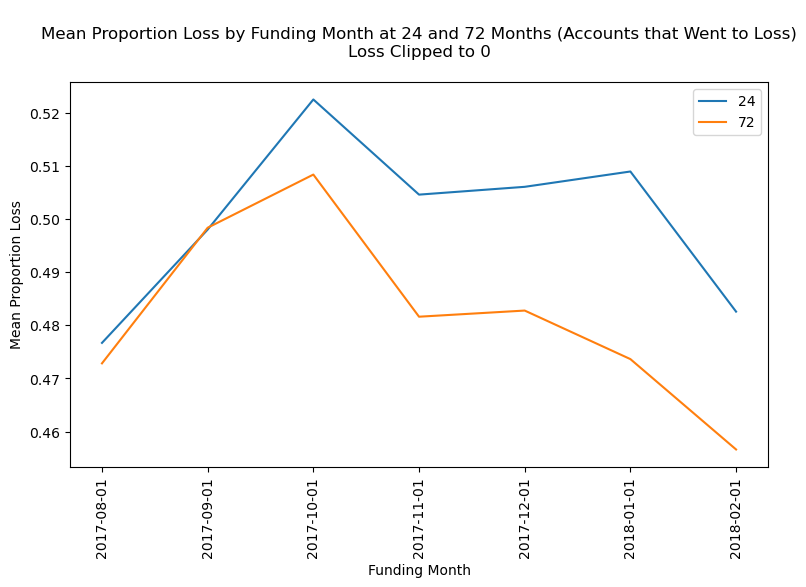

In [13]:
# 24
df_tmp_tmp = df_tmp_2[df_tmp_2['months_on_books'] == 24].copy()
df_tmp_tmp.sort_values(by='dtmFunded_first_x', ascending=True, inplace=True)
df_grouped_24 = df_tmp_tmp.groupby(by='dtmFunded_first_x', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped_24['dtmFunded_first_x'] = df_grouped_24['dtmFunded_first_x'].astype(str)
dict_rename = {
    'prop_loss': 'prop_loss_24',
}
df_grouped_24.rename(columns=dict_rename, inplace=True)
# 72
df_tmp_tmp = df_tmp_2[df_tmp_2['months_on_books'] == 72].copy()
df_tmp_tmp.sort_values(by='dtmFunded_first_x', ascending=True, inplace=True)
df_grouped_72 = df_tmp_tmp.groupby(by='dtmFunded_first_x', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped_72['dtmFunded_first_x'] = df_grouped_72['dtmFunded_first_x'].astype(str)
dict_rename = {
    'prop_loss': 'prop_loss_72',
}
df_grouped_72.rename(columns=dict_rename, inplace=True)
# join
df_tmp_tmp = pd.merge(
    left=df_grouped_24,
    right=df_grouped_72,
    on='dtmFunded_first_x',
    how='inner',
)
# plot
str_title = f"""
Mean Proportion Loss by Funding Month at 24 and 72 Months (Accounts that Went to Loss)
Loss Clipped to 0
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Funding Month')
ax.set_ylabel('Mean Proportion Loss')
ax.plot(df_tmp_tmp['dtmFunded_first_x'], df_tmp_tmp['prop_loss_24'], label='24')
ax.plot(df_tmp_tmp['dtmFunded_first_x'], df_tmp_tmp['prop_loss_72'], label='72')
ax.set_xticklabels(df_tmp_tmp['dtmFunded_first_x'], rotation=90)
plt.legend()
plt.show()

In [14]:
df_tmp_tmp['72_minus_24'] = df_tmp_tmp['prop_loss_72'] - df_tmp_tmp['prop_loss_24']
flt_mean_error = df_tmp_tmp['72_minus_24'].mean()
print(f'Mean Error: {flt_mean_error:0.4f}')
df_tmp_tmp['prop'] = df_tmp_tmp['prop_loss_24'] / df_tmp_tmp['prop_loss_72']
flt_mean_prop = df_tmp_tmp['prop'].mean()
print(f'Factor to Multiply 72 to get 24: {flt_mean_prop:0.4f}')
df_tmp_tmp['factor'] = df_tmp_tmp['prop_loss_72'] / df_tmp_tmp['prop_loss_24']
flt_mean_factor = df_tmp_tmp['factor'].mean()
print(f'Factor to Multiply 24 to get 72: {flt_mean_factor:0.4f}')
# show
df_tmp_tmp

Mean Error: -0.0179
Factor to Multiply 72 to get 24: 1.0375
Factor to Multiply 24 to get 72: 0.9644


,dtmFunded_first_x,prop_loss_24,prop_loss_72,72_minus_24,prop,factor
0,2017-08-01,0.476699,0.472844,-0.003856,1.008154,0.991911
1,2017-09-01,0.498021,0.498369,0.000348,0.999301,1.000699
2,2017-10-01,0.522505,0.508372,-0.014133,1.027800,0.972952
3,2017-11-01,0.504599,0.481624,-0.022975,1.047703,0.954469
4,2017-12-01,0.506067,0.482780,-0.023287,1.048235,0.953985
5,2018-01-01,0.508951,0.473645,-0.035306,1.074541,0.930630
6,2018-02-01,0.482581,0.456639,-0.025942,1.056810,0.946244


## All accounts

### Subset the accounts to funded dates that are in df_tmp

In [15]:
%%time

list_funded_dates = list(df_tmp['dtmFunded_first'])
list_funded_dates = list(dict.fromkeys(list_funded_dates))
df = df[df['dtmFunded_first'].isin(list_funded_dates)]

# show
df

CPU times: user 156 ms, sys: 7.05 ms, total: 163 ms
Wall time: 186 ms


,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType
160157,1165170,2013-09-01,13.0,26706.48,22075.00,1.209807,Franchise
161263,1181789,2013-08-01,13.0,18770.24,25985.25,0.722342,Franchise
162221,1195329,2013-08-01,13.0,17999.81,12600.00,1.428556,Independent
162615,1205105,2013-08-01,7.0,20067.07,16375.00,1.225470,Franchise
162930,1209408,2013-08-01,NaN,17733.51,12850.00,1.380040,Franchise
...,...,...,...,...,...,...,...
384432,5936418,2022-02-01,NaN,20913.46,13225.00,1.581358,Franchise
384454,5938021,2022-02-01,NaN,28229.72,20475.00,1.378741,Independent
384465,5939243,2022-02-01,NaN,25351.86,23070.00,1.098910,Independent
384467,5939508,2022-02-01,NaN,18121.20,17292.00,1.047953,Independent


### Make sure we have corresponding months on books for everything in df_tmp

In [16]:
list_df = []
for funded_date in tqdm(list_funded_dates):
    # subset
    df_tmp_2 = df_tmp[df_tmp['dtmFunded_first'] == funded_date].copy()
    # get unique values for mob
    list_int_mob = list(df_tmp_2['months_on_books'].unique())
    # subset df
    for int_mob in list_int_mob:
        df_2 = df[df['dtmFunded_first'] == funded_date].copy()
        # assign mob
        df_2['months_on_books'] = int_mob
        # append
        list_df.append(df_2)
df = pd.concat(list_df)
df

100%|██████████| 103/103 [00:00<00:00, 477.08it/s]


,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType,months_on_books
175897,1426513,2014-04-01,13.0,16193.20,12350.0,1.311190,Franchise,72
176954,1450352,2014-04-01,13.0,15775.95,10050.0,1.569746,Franchise,72
177311,1371397,2014-04-01,13.0,17965.63,19277.0,0.931972,Independent,72
177605,1462677,2014-04-01,13.0,13391.88,16523.0,0.810499,Franchise,72
178137,1473430,2014-04-01,13.0,17245.75,10775.0,1.600534,Franchise,72
...,...,...,...,...,...,...,...,...
381489,5879244,2021-12-01,NaN,13170.58,8232.0,1.599925,Independent,24
381492,5879325,2021-12-01,7.0,21153.74,16923.0,1.249999,Franchise,24
381495,5879478,2021-12-01,NaN,19984.00,15874.0,1.258914,Independent,24
381497,5879644,2021-12-01,NaN,17126.07,11262.0,1.520695,Independent,24


### Join

In [17]:
%%time

df = pd.merge(
    left=df,
    right=df_tmp,
    on=['bigAccountId','months_on_books'],
    how='left',
)
dict_rename = {
    'dtmFunded_first_x': 'dtmFunded_first',
}
df.rename(columns=dict_rename, inplace=True)
list_cols = [
    'dtmFunded_first_y',
    'MonthEndDate_first',
]
df.drop(list_cols, axis=1, inplace=True)
df['fltNetChgOff'] = df['fltNetChgOff'].fillna(0)
if bool_clip_negative_loss:
    df['fltNetChgOff'] = df['fltNetChgOff'].clip(lower=0)
else:
    pass
df['intOpenBKType'] = df['intOpenBKType'].astype(str)
df['prop_loss'] = df['fltNetChgOff'] / df['AmtFinanced']
df.sort_values(by=['bigAccountId','months_on_books'], ascending=True, inplace=True)
df

CPU times: user 217 ms, sys: 15.2 ms, total: 232 ms
Wall time: 245 ms


,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType,months_on_books,fltNetChgOff,prop_loss
7625,1148520,2013-08-01,nan,20725.04,14125.0,1.467259,Franchise,72,11659.20,0.562566
13938,1165170,2013-09-01,13.0,26706.48,22075.0,1.209807,Franchise,72,0.00,0.000000
7641,1165284,2013-08-01,13.0,17956.25,13025.0,1.378599,Independent,72,0.00,0.000000
13948,1173622,2013-09-01,13.0,19216.15,17425.0,1.102792,Franchise,72,0.00,0.000000
7679,1176592,2013-08-01,13.0,16046.43,17800.0,0.901485,Franchise,72,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...
196362,5939992,2022-02-01,nan,12969.90,10375.0,1.250111,Independent,24,0.00,0.000000
196002,5940339,2022-02-01,nan,23990.99,20537.0,1.168184,Independent,24,0.00,0.000000
196003,5940766,2022-02-01,nan,24780.00,18500.0,1.339459,Independent,24,12529.10,0.505613
195879,5941420,2022-02-01,nan,12960.12,9126.0,1.420131,Independent,24,11251.67,0.868176


### Quick plots

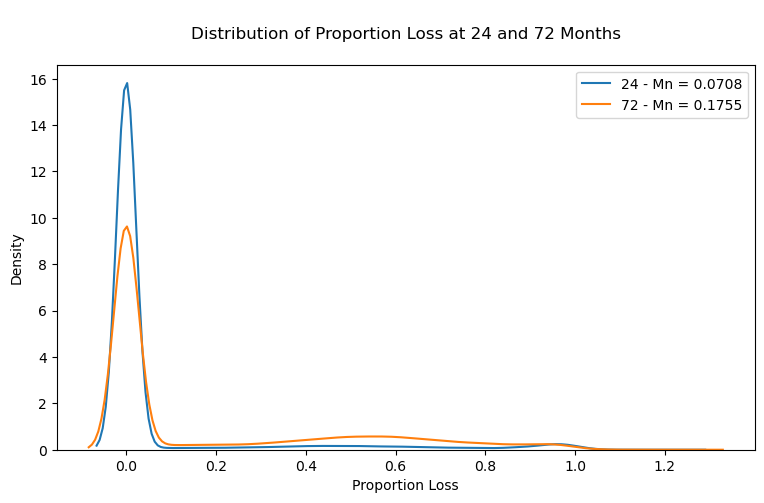

In [18]:
# 24
df_tmp_24 = df[df['months_on_books'] == 24].copy()
list_24 = list(df_tmp_24['prop_loss'])
flt_mean_24 = np.mean(list_24)
str_label_24 = f'24 - Mn = {flt_mean_24:0.4f}'
# 72
df_tmp_72 = df[df['months_on_books'] == 72].copy()
list_72 = list(df_tmp_72['prop_loss'])
flt_mean_72 = np.mean(list_72)
str_label_72 = f'72 - Mn = {flt_mean_72:0.4f}'
# title
str_title = f"""
Distribution of Proportion Loss at 24 and 72 Months
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Proportion Loss')
sns.kdeplot(list_24, ax=ax, label=str_label_24)
sns.kdeplot(list_72, ax=ax, label=str_label_72)
plt.legend()
plt.show()

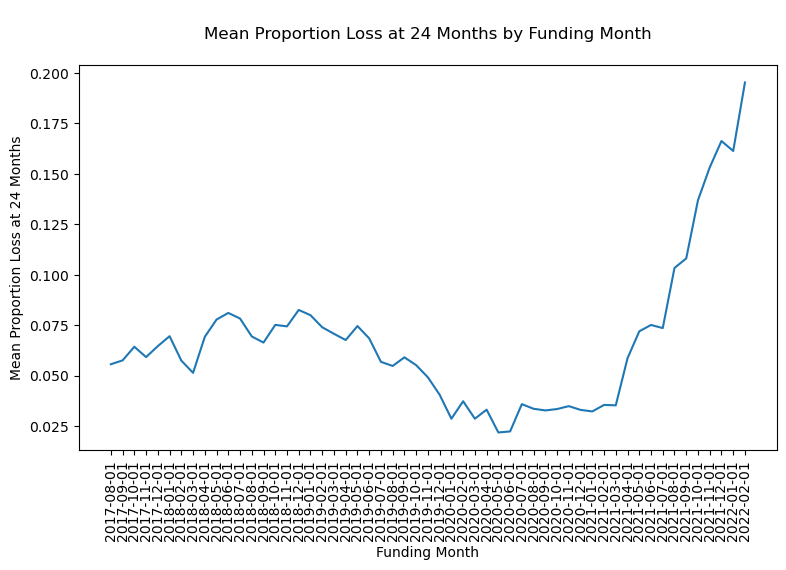

In [19]:
# loss over time
int_n_months = 24
df_tmp = df[df['months_on_books'] == int_n_months].copy()
df_tmp.sort_values(by='dtmFunded_first', ascending=True, inplace=True)
df_grouped = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped['dtmFunded_first'] = df_grouped['dtmFunded_first'].astype(str)
# plot
str_title = f"""
Mean Proportion Loss at {int_n_months} Months by Funding Month
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Funding Month')
ax.set_ylabel(f'Mean Proportion Loss at {int_n_months} Months')
ax.plot(df_grouped['dtmFunded_first'], df_grouped['prop_loss'])
ax.set_xticklabels(df_grouped['dtmFunded_first'], rotation=90)
plt.show()

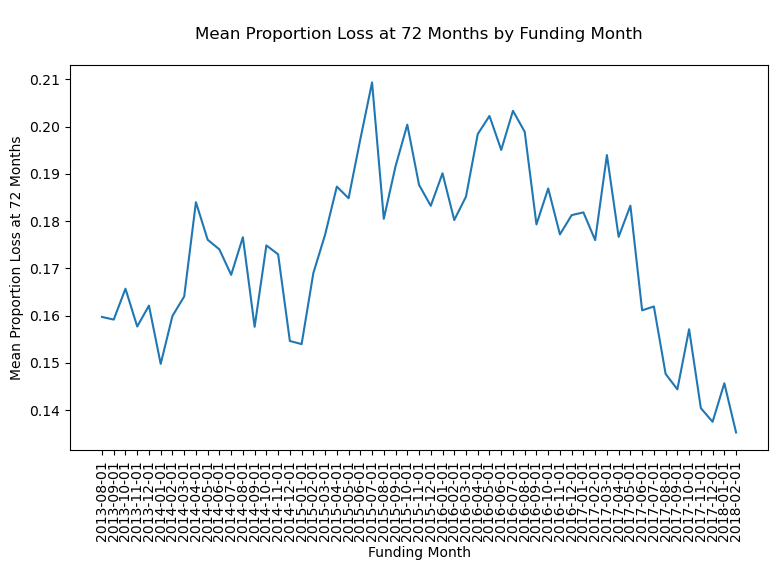

In [20]:
# loss over time
int_n_months = 72
df_tmp = df[df['months_on_books'] == int_n_months].copy()
df_tmp.sort_values(by='dtmFunded_first', ascending=True, inplace=True)
df_grouped = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped['dtmFunded_first'] = df_grouped['dtmFunded_first'].astype(str)
# plot
str_title = f"""
Mean Proportion Loss at {int_n_months} Months by Funding Month
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Funding Month')
ax.set_ylabel(f'Mean Proportion Loss at {int_n_months} Months')
ax.plot(df_grouped['dtmFunded_first'], df_grouped['prop_loss'])
ax.set_xticklabels(df_grouped['dtmFunded_first'], rotation=90)
plt.show()

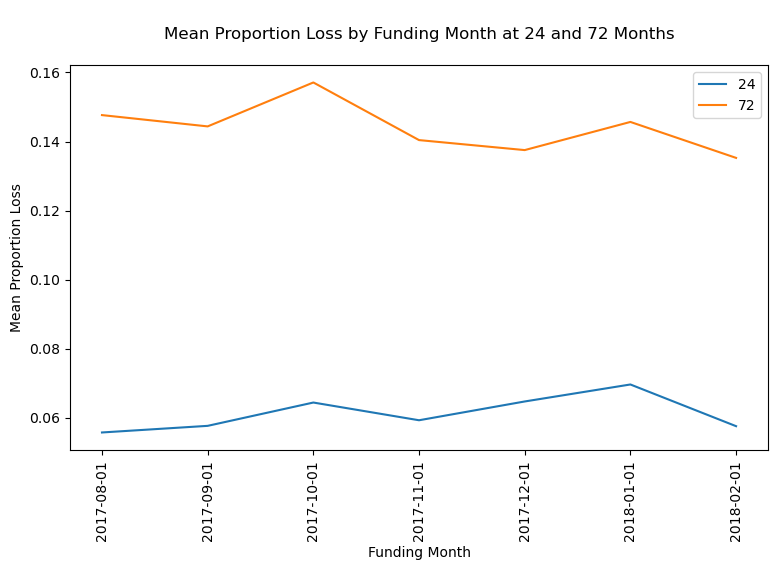

In [21]:
# 24
df_tmp = df[df['months_on_books'] == 24].copy()
df_tmp.sort_values(by='dtmFunded_first', ascending=True, inplace=True)
df_grouped_24 = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped_24['dtmFunded_first'] = df_grouped_24['dtmFunded_first'].astype(str)
dict_rename = {
    'prop_loss': 'prop_loss_24',
}
df_grouped_24.rename(columns=dict_rename, inplace=True)
# 72
df_tmp = df[df['months_on_books'] == 72].copy()
df_tmp.sort_values(by='dtmFunded_first', ascending=True, inplace=True)
df_grouped_72 = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
})
df_grouped_72['dtmFunded_first'] = df_grouped_72['dtmFunded_first'].astype(str)
dict_rename = {
    'prop_loss': 'prop_loss_72',
}
df_grouped_72.rename(columns=dict_rename, inplace=True)
# join
df_tmp = pd.merge(
    left=df_grouped_24,
    right=df_grouped_72,
    on='dtmFunded_first',
    how='inner',
)
# plot
str_title = f"""
Mean Proportion Loss by Funding Month at 24 and 72 Months
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Funding Month')
ax.set_ylabel('Mean Proportion Loss')
ax.plot(df_tmp['dtmFunded_first'], df_tmp['prop_loss_24'], label='24')
ax.plot(df_tmp['dtmFunded_first'], df_tmp['prop_loss_72'], label='72')
ax.set_xticklabels(df_tmp['dtmFunded_first'], rotation=90)
plt.legend()
plt.show()

### Quick Analysis

In [22]:
df_tmp['72_minus_24'] = df_tmp['prop_loss_72'] - df_tmp['prop_loss_24']
flt_mean_error = df_tmp['72_minus_24'].mean()
print(f'Mean Error: {flt_mean_error:0.4f}')
df_tmp['prop'] = df_tmp['prop_loss_24'] / df_tmp['prop_loss_72']
flt_mean_prop = df_tmp['prop'].mean()
print(f'Factor to Multiply 72 to get 24: {flt_mean_prop:0.4f}')
df_tmp['factor'] = df_tmp['prop_loss_72'] / df_tmp['prop_loss_24']
flt_mean_factor = df_tmp['factor'].mean()
print(f'Factor to Multiply 24 to get 72: {flt_mean_factor:0.4f}')
# show
df_tmp

Mean Error: 0.0827
Factor to Multiply 72 to get 24: 0.4262
Factor to Multiply 24 to get 72: 2.3612


,dtmFunded_first,prop_loss_24,prop_loss_72,72_minus_24,prop,factor
0,2017-08-01,0.055736,0.147651,0.091916,0.377482,2.649129
1,2017-09-01,0.057653,0.144379,0.086726,0.399319,2.504262
2,2017-10-01,0.064406,0.157101,0.092695,0.409965,2.439231
3,2017-11-01,0.059274,0.140413,0.081138,0.422143,2.368863
4,2017-12-01,0.064714,0.137517,0.072804,0.470585,2.125013
5,2018-01-01,0.069636,0.145672,0.076035,0.478036,2.091894
6,2018-02-01,0.057559,0.135260,0.077701,0.425542,2.349943


### Write to s3

In [23]:
str_filename = 'df_loss_all.gzip'
str_uri = f's3://{str_project}/{str_task}/{str_subtask}/{str_filename}'
df.to_parquet(str_uri, compression='gzip')